In [2]:
import pandas as pd

file_path ="C:/Users/65977/Downloads/DSA3101/amazon_delivery.csv"
df= pd.read_csv(file_path)

print(df.head())

        Order_ID  Agent_Age  Agent_Rating  Store_Latitude  Store_Longitude  \
0  ialx566343618         37           4.9       22.745049        75.892471   
1  akqg208421122         34           4.5       12.913041        77.683237   
2  njpu434582536         23           4.4       12.914264        77.678400   
3  rjto796129700         38           4.7       11.003669        76.976494   
4  zguw716275638         32           4.6       12.972793        80.249982   

   Drop_Latitude  Drop_Longitude  Order_Date Order_Time Pickup_Time  \
0      22.765049       75.912471  2022-03-19   11:30:00    11:45:00   
1      13.043041       77.813237  2022-03-25   19:45:00    19:50:00   
2      12.924264       77.688400  2022-03-19   08:30:00    08:45:00   
3      11.053669       77.026494  2022-04-05   18:00:00    18:10:00   
4      13.012793       80.289982  2022-03-26   13:30:00    13:45:00   

      Weather  Traffic      Vehicle            Area  Delivery_Time  \
0       Sunny    High   motorcycle

Step 1: Data Preparation and Cleaning
1.1 Check for missing values

In [3]:
print(df.isnull().sum())
df = df.dropna() #51 rows of agent rating and 91 rows of weather dropped since <1% of data

Order_ID            0
Agent_Age           0
Agent_Rating       54
Store_Latitude      0
Store_Longitude     0
Drop_Latitude       0
Drop_Longitude      0
Order_Date          0
Order_Time          0
Pickup_Time         0
Weather            91
Traffic             0
Vehicle             0
Area                0
Delivery_Time       0
Category            0
dtype: int64


1.2 Convert columns to appropriate formats

In [4]:
# Convert Order_Time and Pickup_Time to datetime
df['Order_Time'] = pd.to_datetime(df['Order_Time'], format='%H:%M:%S').dt.time
df['Pickup_Time'] = pd.to_datetime(df['Pickup_Time'], format='%H:%M:%S').dt.time

# Convert Order_Date to datetime format
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

1.3 Calculate Order-Pickup Lag

In [35]:
#Combine Order_Date with times
df['Order_DateTime'] = pd.to_datetime(df['Order_Date'].astype(str) + ' ' + df['Order_Time'].astype(str))
df['Pickup_DateTime'] = pd.to_datetime(df['Order_Date'].astype(str) + ' ' + df['Pickup_Time'].astype(str))

#Calculate lag between order and pickup(in minutes)
df['Order_Pickup_Lag'] = (df['Pickup_DateTime'] - df['Order_DateTime']).dt.total_seconds() / 60
print(df.head())


        Order_ID  Agent_Age  Agent_Rating  Store_Latitude  Store_Longitude  \
0  ialx566343618         37           4.9       22.745049        75.892471   
1  akqg208421122         34           4.5       12.913041        77.683237   
2  njpu434582536         23           4.4       12.914264        77.678400   
3  rjto796129700         38           4.7       11.003669        76.976494   
4  zguw716275638         32           4.6       12.972793        80.249982   

   Drop_Latitude  Drop_Longitude Order_Date Order_Time Pickup_Time  ...  \
0      22.765049       75.912471 2022-03-19   11:30:00    11:45:00  ...   
1      13.043041       77.813237 2022-03-25   19:45:00    19:50:00  ...   
2      12.924264       77.688400 2022-03-19   08:30:00    08:45:00  ...   
3      11.053669       77.026494 2022-04-05   18:00:00    18:10:00  ...   
4      13.012793       80.289982 2022-03-26   13:30:00    13:45:00  ...   

       Order_DateTime     Pickup_DateTime  Order_Pickup_Lag  Distance_km  \
0 20

1.4 Calculate Geographical Distance using Haversine formula:

In [6]:
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    # Convert latitude and longitude from degrees to radians
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    
    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    R = 6371  # Radius of the Earth in km
    return R * c

# Apply the function to calculate distance for each row
df['Distance_km'] = df.apply(lambda row: haversine(row['Store_Latitude'], 
                                                   row['Store_Longitude'], 
                                                   row['Drop_Latitude'], 
                                                   row['Drop_Longitude']), axis=1)
print(df.head())


        Order_ID  Agent_Age  Agent_Rating  Store_Latitude  Store_Longitude  \
0  ialx566343618         37           4.9       22.745049        75.892471   
1  akqg208421122         34           4.5       12.913041        77.683237   
2  njpu434582536         23           4.4       12.914264        77.678400   
3  rjto796129700         38           4.7       11.003669        76.976494   
4  zguw716275638         32           4.6       12.972793        80.249982   

   Drop_Latitude  Drop_Longitude Order_Date Order_Time Pickup_Time  \
0      22.765049       75.912471 2022-03-19   11:30:00    11:45:00   
1      13.043041       77.813237 2022-03-25   19:45:00    19:50:00   
2      12.924264       77.688400 2022-03-19   08:30:00    08:45:00   
3      11.053669       77.026494 2022-04-05   18:00:00    18:10:00   
4      13.012793       80.289982 2022-03-26   13:30:00    13:45:00   

      Weather  Traffic      Vehicle            Area  Delivery_Time  \
0       Sunny    High   motorcycle      

Step 2: EDA
2.1 Summary

In [7]:
print(df[['Delivery_Time', 'Order_Pickup_Lag']].describe())

       Delivery_Time  Order_Pickup_Lag
count   43594.000000      43594.000000
mean      124.916433        -17.260403
std        51.941975        196.015502
min        10.000000      -1435.000000
25%        90.000000          5.000000
50%       125.000000         10.000000
75%       160.000000         15.000000
max       270.000000         15.000000


2.2 Visualize Delivery Time vs Key Factors:


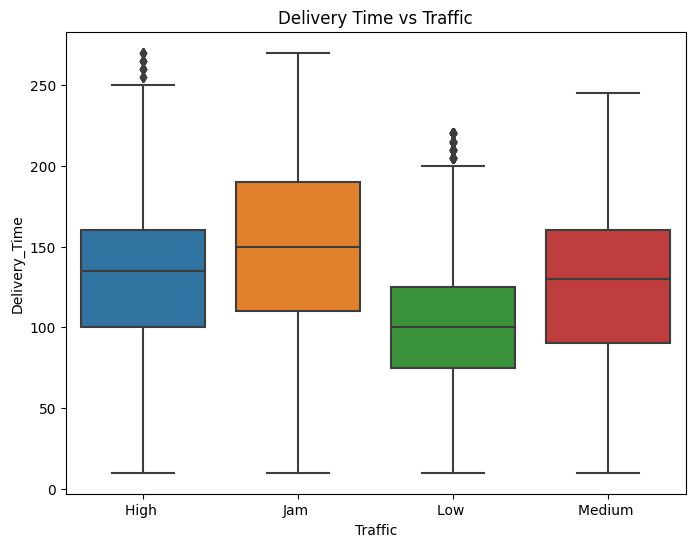

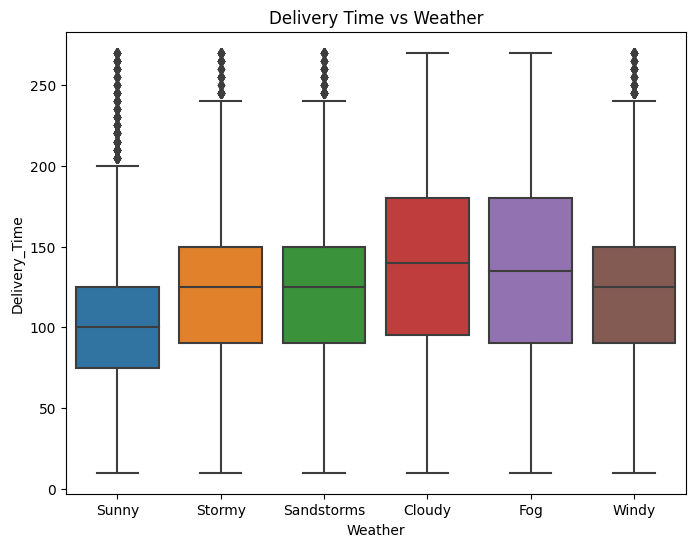

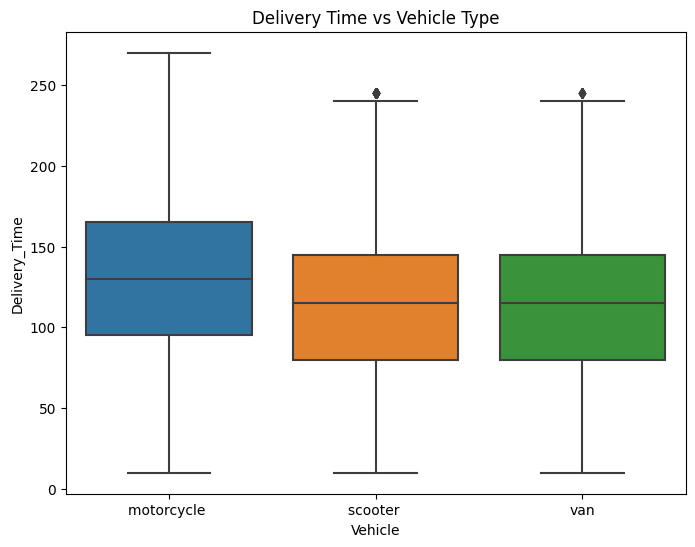

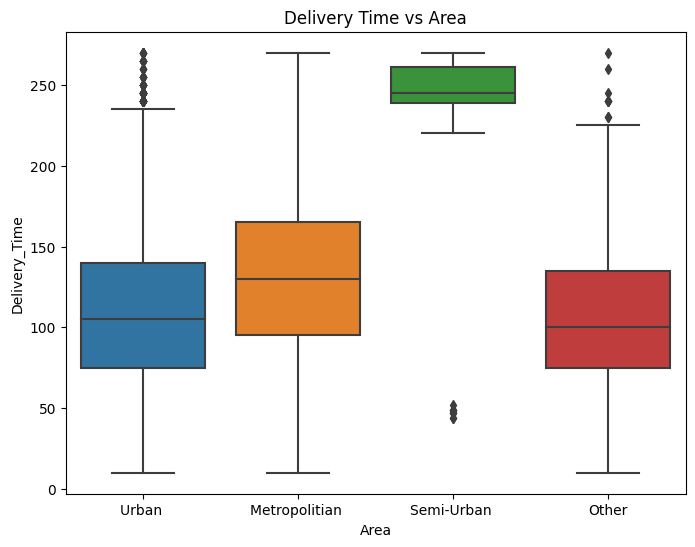

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Delivery Time vs Traffic
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Traffic', y='Delivery_Time')
plt.title('Delivery Time vs Traffic')
plt.show()

# Delivery Time vs Weather
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Weather', y='Delivery_Time')
plt.title('Delivery Time vs Weather')
plt.show()

# Delivery Time vs Vehicle Type
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Vehicle', y='Delivery_Time')
plt.title('Delivery Time vs Vehicle Type')
plt.show()

# Delivery Time vs Area
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Area', y='Delivery_Time')
plt.title('Delivery Time vs Area')
plt.show()


2.3 Create bins for distance (in km)

  Distance_Category  Delivery_Time
0             Short     105.372093
1            Medium     115.468031
2              Long     141.937469
3         Very Long     141.706318


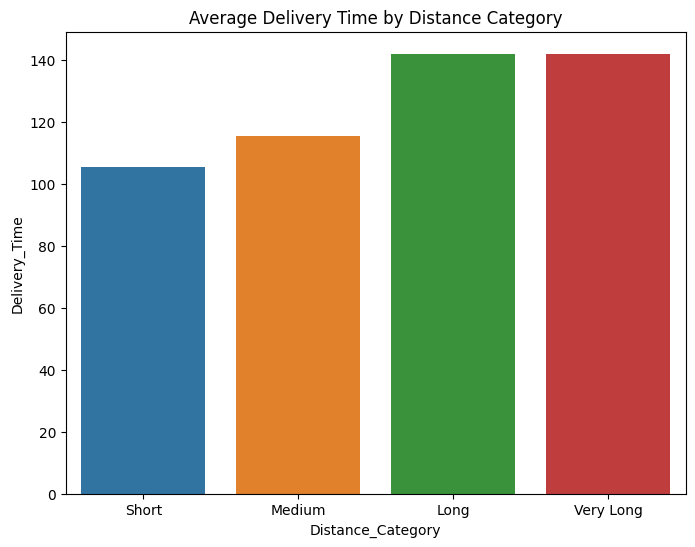

In [9]:
bins = [0, 5, 10, 20, 50]
labels = ['Short', 'Medium', 'Long', 'Very Long']
df['Distance_Category'] = pd.cut(df['Distance_km'], bins=bins, labels=labels)

# Group by Distance_Category and calculate average delivery time
distance_summary = df.groupby('Distance_Category')['Delivery_Time'].mean().reset_index()
print(distance_summary)

plt.figure(figsize=(8, 6))
sns.barplot(data=distance_summary, x='Distance_Category', y='Delivery_Time')
plt.title('Average Delivery Time by Distance Category')
plt.show()

Step 3: Feature Engineering
3.1 Extract Time-Based Features

In [10]:
#Extract hour from order time
df['Order_Hour'] = df['Order_DateTime'].dt.hour

#Extract day of the week (0=monday, 6=sunday)
df['Order_DayOfWeek'] = df['Order_DateTime'].dt.dayofweek

# Create a new column for part of day
def get_part_of_day(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df['Part_of_Day'] = df['Order_Hour'].apply(get_part_of_day)
print(df[['Order_DateTime', 'Order_Hour', 'Order_DayOfWeek', 'Part_of_Day']].head())
print(df.head())


       Order_DateTime  Order_Hour  Order_DayOfWeek Part_of_Day
0 2022-03-19 11:30:00          11                5     Morning
1 2022-03-25 19:45:00          19                4     Evening
2 2022-03-19 08:30:00           8                5     Morning
3 2022-04-05 18:00:00          18                1     Evening
4 2022-03-26 13:30:00          13                5   Afternoon
        Order_ID  Agent_Age  Agent_Rating  Store_Latitude  Store_Longitude  \
0  ialx566343618         37           4.9       22.745049        75.892471   
1  akqg208421122         34           4.5       12.913041        77.683237   
2  njpu434582536         23           4.4       12.914264        77.678400   
3  rjto796129700         38           4.7       11.003669        76.976494   
4  zguw716275638         32           4.6       12.972793        80.249982   

   Drop_Latitude  Drop_Longitude Order_Date Order_Time Pickup_Time  ...  \
0      22.765049       75.912471 2022-03-19   11:30:00    11:45:00  ...   
1  

3.2 Define peak hours (10am-8pm)

In [11]:
def is_peak_hour(hour):
    return 10 <= hour <= 20

df['Is_Peak_Hour'] = df['Order_Hour'].apply(is_peak_hour)
print(df[['Order_Hour', 'Is_Peak_Hour']].head())

   Order_Hour  Is_Peak_Hour
0          11          True
1          19          True
2           8         False
3          18          True
4          13          True

3.3 Analyze Delivery Performance by New Features

In [12]:
# Group by Part of Day and calculate average delivery time
part_of_day_summary = df.groupby('Part_of_Day')['Delivery_Time'].mean().reset_index()
print(part_of_day_summary)

# Group by Is_Peak_Hour and calculate average delivery time
peak_hour_summary = df.groupby('Is_Peak_Hour')['Delivery_Time'].mean().reset_index()
print(peak_hour_summary)

  Part_of_Day  Delivery_Time
0   Afternoon     122.102806
1     Evening     138.857866
2     Morning     101.126125
3       Night     121.091662
   Is_Peak_Hour  Delivery_Time
0         False     115.162366
1          True     131.690481


3.4 Visualize New Features’ Impact on Delivery Time

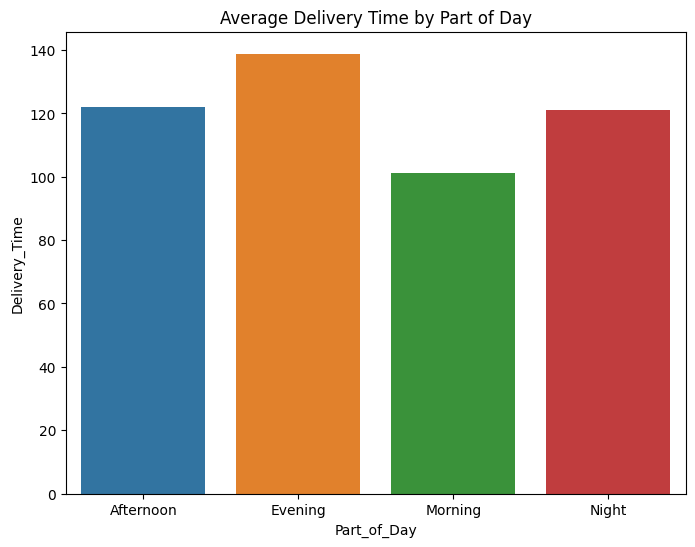

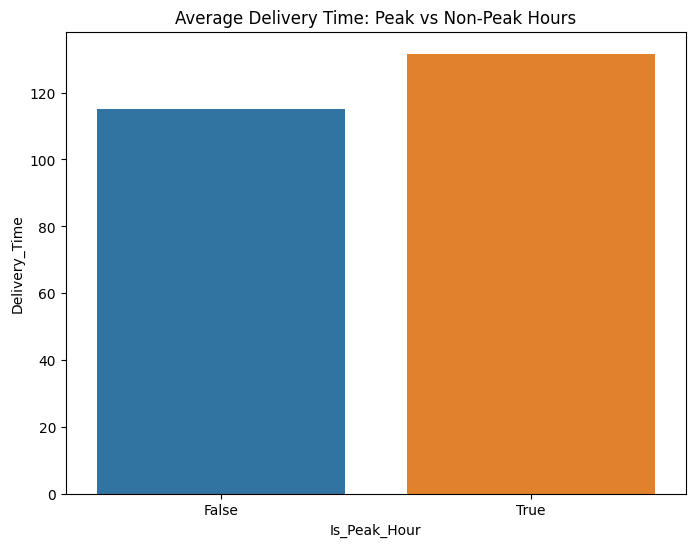

In [13]:
# peak hour vs delivery time
# which part of day vs delivery time
# day of week vs delivery time

#delivery time by part of day
plt.figure(figsize=(8, 6))
sns.barplot(data=part_of_day_summary, x='Part_of_Day', y='Delivery_Time')
plt.title('Average Delivery Time by Part of Day')
plt.show()

#delivery time during peak vs non-peak
plt.figure(figsize=(8, 6))
sns.barplot(data=peak_hour_summary, x='Is_Peak_Hour', y='Delivery_Time')
plt.title('Average Delivery Time: Peak vs Non-Peak Hours')
plt.show()

   Order_DayOfWeek  Delivery_Time        Day
0                0     124.785450     Monday
1                1     120.304534    Tuesday
2                2     131.669815  Wednesday
3                3     119.794113   Thursday
4                4     126.927457     Friday
5                5     124.967983   Saturday
6                6     124.967391     Sunday


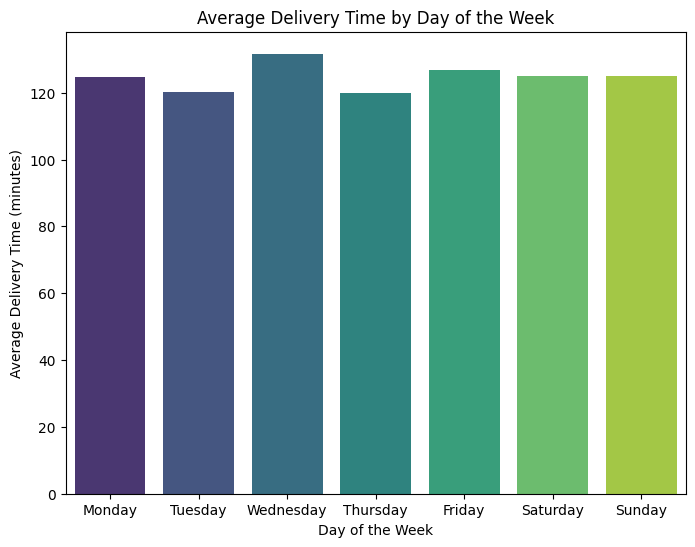

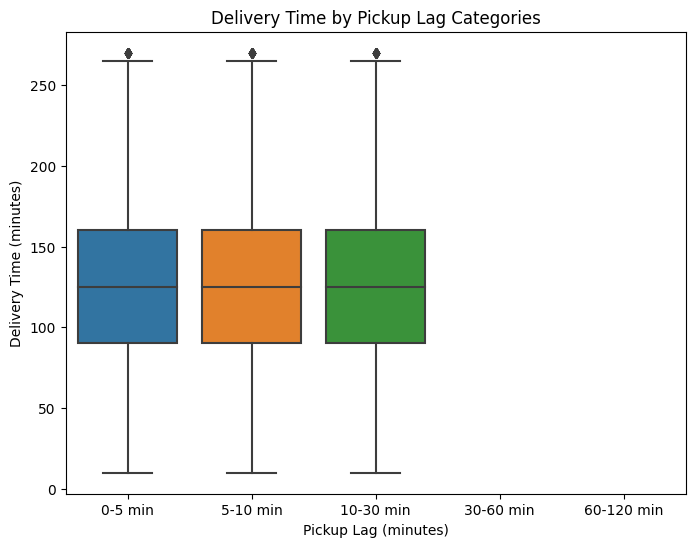

In [14]:
day_of_week_summary = df.groupby('Order_DayOfWeek')['Delivery_Time'].mean().reset_index()

day_of_week_summary['Day'] = day_of_week_summary['Order_DayOfWeek'].map(
    {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
)

print(day_of_week_summary)

#delivery time by day of the week
plt.figure(figsize=(8, 6))
sns.barplot(data=day_of_week_summary, x='Day', y='Delivery_Time', palette='viridis')
plt.title('Average Delivery Time by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Average Delivery Time (minutes)')
plt.show()


#Create bins for pickup lag to group into categories
df['Pickup_Lag_Category'] = pd.cut(df['Order_Pickup_Lag'], bins=[0, 5, 10, 30, 60, 120], 
                            labels=['0-5 min', '5-10 min', '10-30 min', '30-60 min', '60-120 min'])

#Boxplot to visualize delivery time across pickup lag categories
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Pickup_Lag_Category', y='Delivery_Time')
plt.title('Delivery Time by Pickup Lag Categories')
plt.xlabel('Pickup Lag (minutes)')
plt.ylabel('Delivery Time (minutes)')
plt.show()

3.5 Correlation Between Features

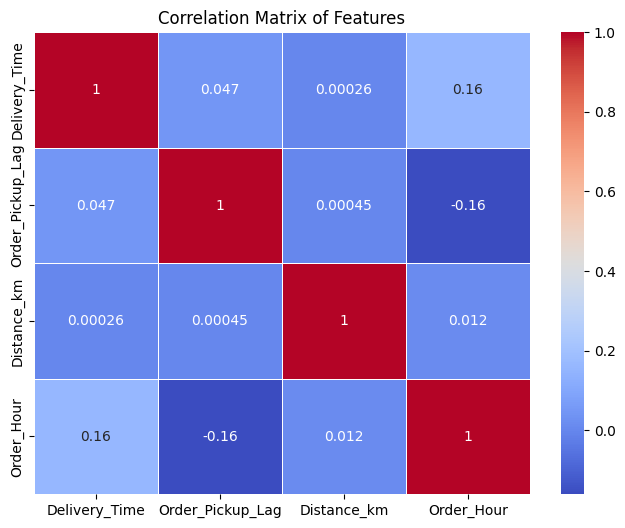

In [15]:
correlation_matrix = df[['Delivery_Time', 'Order_Pickup_Lag', 'Distance_km', 'Order_Hour']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Features')
plt.show()

Step 4: Predictive Modeling
4.1 Prepare the Data for Modeling

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode categorical variables
label_encoders = {}
for column in ['Traffic', 'Weather', 'Vehicle', 'Area']:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le  # Save the encoders for future use

#Define features X and y
X = df[['Agent_Age', 'Agent_Rating', 'Distance_km', 'Order_Pickup_Lag', 'Traffic', 'Weather', 'Vehicle', 'Area']]
y = df['Delivery_Time']

#80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

4.2 Training Linear R

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialize and train the model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions on test 
y_pred = lr_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

Mean Squared Error: 2046.5378120116166
R-squared: 0.22179577664069516


4.3 Train decision trees

In [18]:
from sklearn.tree import DecisionTreeRegressor

# Initialize and train the decision tree regressor
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

# Make predictions on test
y_pred_dt = dt_model.predict(X_test)

# Evaluate the model
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print(f'Decision Tree - Mean Squared Error: {mse_dt}')
print(f'Decision Tree - R-squared: {r2_dt}')

Decision Tree - Mean Squared Error: 2500.2416848262415
Decision Tree - R-squared: 0.049273056607604504


4.4 Interpret results

            Feature  Importance
2       Distance_km    0.292664
1      Agent_Rating    0.210768
5           Weather    0.164757
0         Agent_Age    0.134809
4           Traffic    0.111103
3  Order_Pickup_Lag    0.036296
6           Vehicle    0.030939
7              Area    0.018664


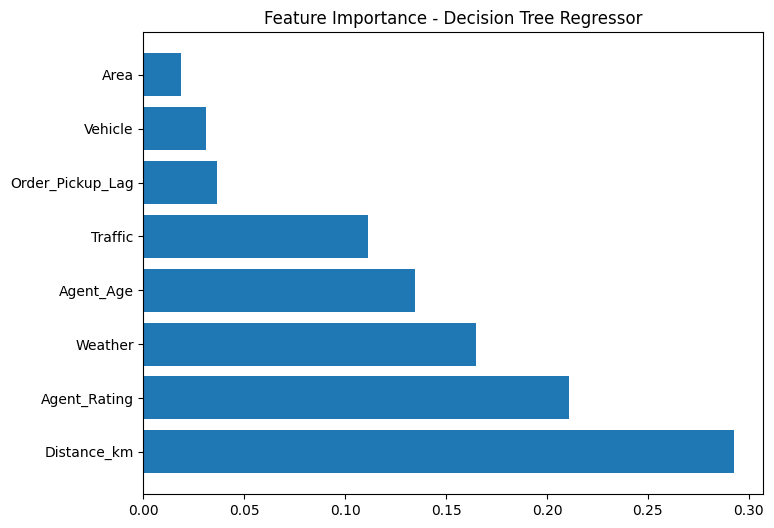

In [19]:
# Feature importance for Decision Tree
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance)

# Plot feature importance
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.title('Feature Importance - Decision Tree Regressor')
plt.show()

4.5 Plot Linear regression model

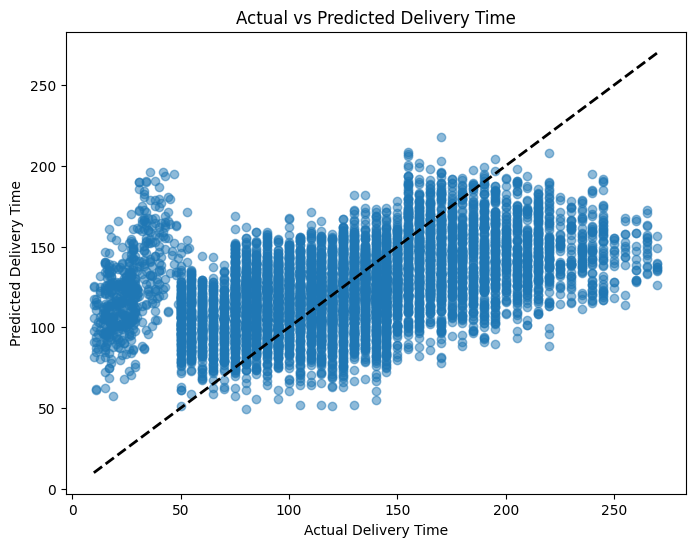

In [20]:
# Plot predictions vs actual values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Delivery Time')
plt.ylabel('Predicted Delivery Time')
plt.title('Actual vs Predicted Delivery Time')
plt.show()

4.6 Analyze Model Coefficient in LR

            Feature  Coefficient
0         Agent_Age     2.004592
1      Agent_Rating   -44.520225
2       Distance_km     0.000522
3  Order_Pickup_Lag     0.011172
4           Traffic    -7.678584
5           Weather    -4.997279
6           Vehicle    -9.692817
7              Area    -4.784487


<Figure size 800x600 with 0 Axes>

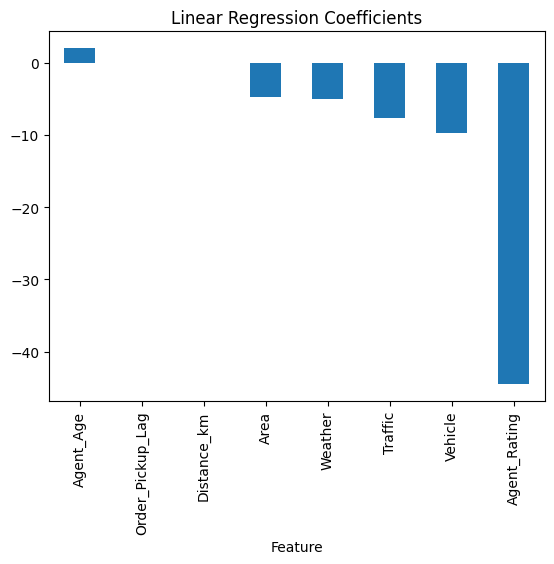

In [21]:
# Get the coefficients of the linear regression model
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
})

print(coefficients)

# Plot the coefficients for visualization
plt.figure(figsize=(8, 6))
coefficients.sort_values(by='Coefficient', ascending=False).plot(kind='bar', x='Feature', y='Coefficient', legend=False)
plt.title('Linear Regression Coefficients')
plt.show()

Applying optimisation Strategies on dataset

1.Assign High-Rated Agents to Priority Deliveries

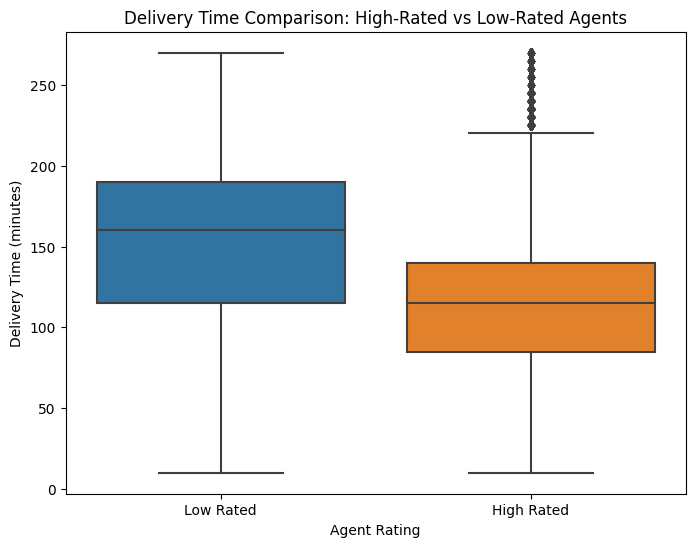

In [22]:
# Filter high-rated agents (Agent_Rating >= 4.5)
priority_agents = df[df['Agent_Rating'] >= 4.5]

# Compare delivery time between high-rated and lower-rated agents
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x=pd.cut(df['Agent_Rating'], bins=[0, 4.5, 5], labels=['Low Rated', 'High Rated']), 
            y='Delivery_Time')
plt.title('Delivery Time Comparison: High-Rated vs Low-Rated Agents')
plt.xlabel('Agent Rating')
plt.ylabel('Delivery Time (minutes)')
plt.show()

2.Use Route Optimization for Longer Distances

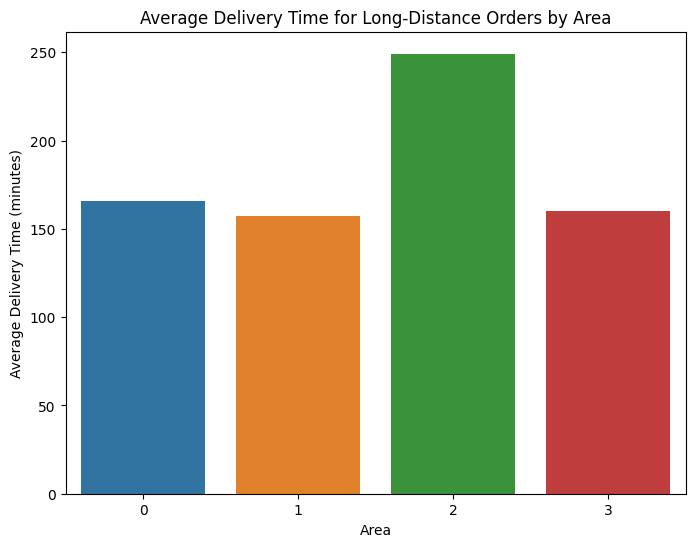

In [23]:
#Identify Long-Distance Deliveries
mean_distance = df['Delivery_Time'].mean()
long_distance_orders = df[df['Delivery_Time'] > mean_distance]

# Group Long-Distance Orders by Area and Calculate Average Delivery Time
grouped_orders = long_distance_orders.groupby('Area')['Delivery_Time'].mean().reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(data=grouped_orders, x='Area', y='Delivery_Time')
plt.title('Average Delivery Time for Long-Distance Orders by Area')
plt.xlabel('Area')
plt.ylabel('Average Delivery Time (minutes)')
plt.show()

# Insight: Optimize deliveries in areas with higher delivery times to improve efficiency.

3.Adjust Staffing and Delivery Schedules Based on Traffic and Weather

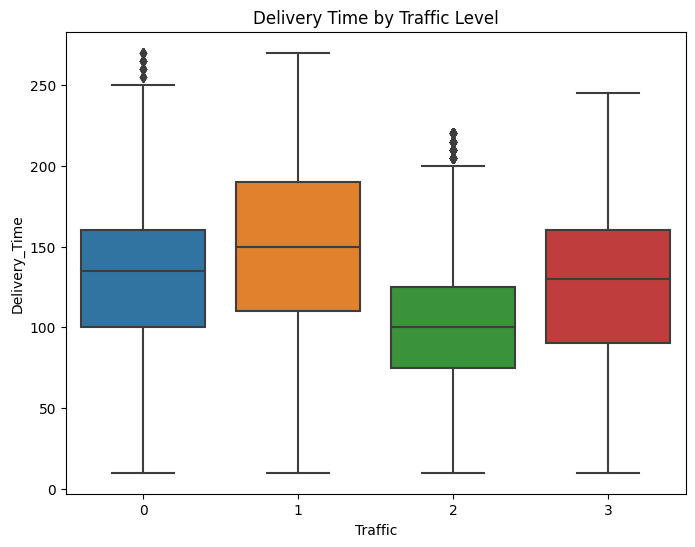

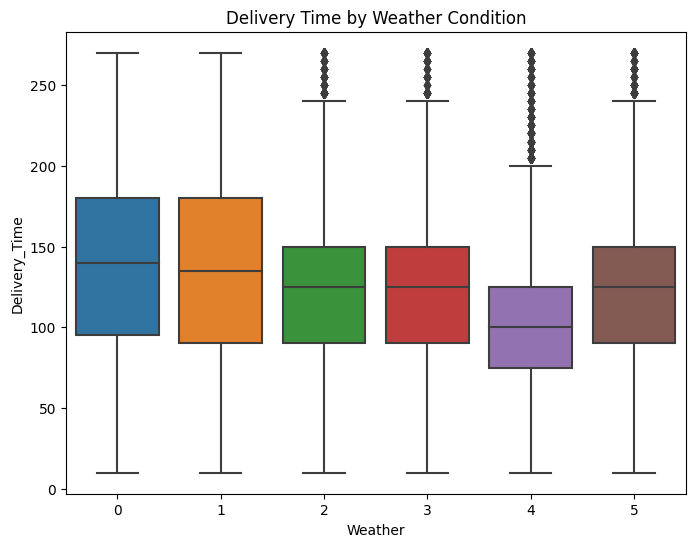

In [24]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Traffic', y='Delivery_Time')
plt.title('Delivery Time by Traffic Level')
plt.show()

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Weather', y='Delivery_Time')
plt.title('Delivery Time by Weather Condition')
plt.show()
# Insight: Schedule more agents during peak traffic and adverse weather conditions.

3.1

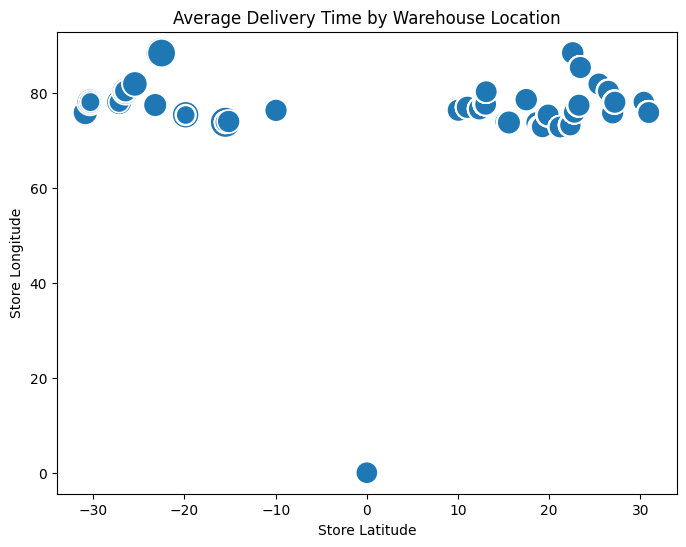

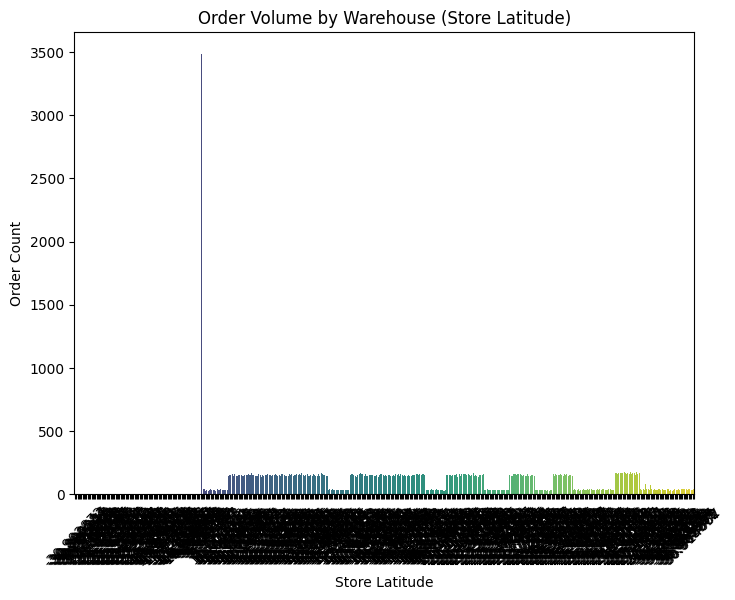

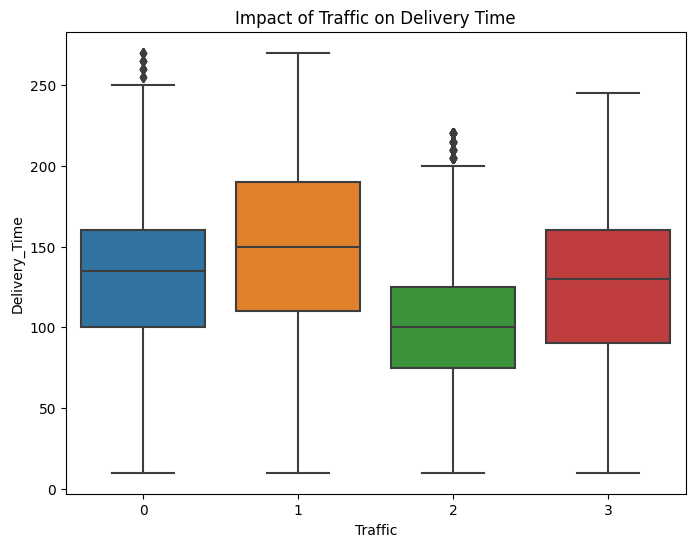

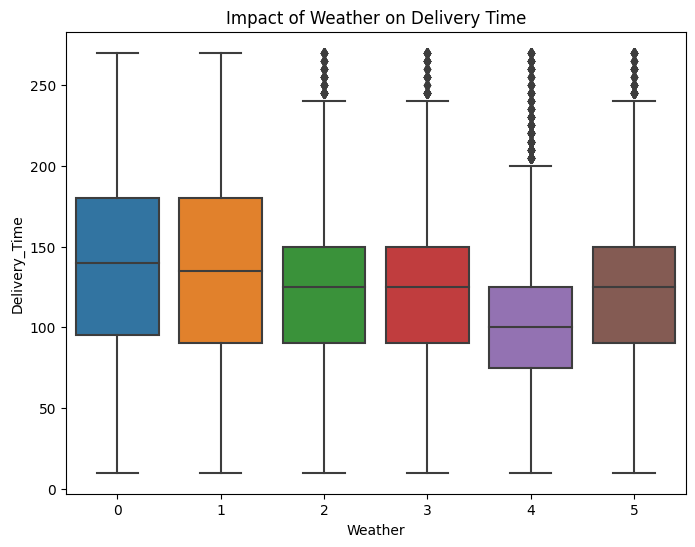

Warehouses with Delays (Bottlenecks):
     Store_Latitude  Store_Longitude  Average_Delivery_Time
1        -30.899584        75.809346             127.500000
5        -30.885915        75.788259             150.000000
6        -30.885814        75.786976             180.000000
7        -30.873988        75.842739             155.000000
8        -30.372202        78.077151             145.000000
..              ...              ...                    ...
483       30.895817        75.813112             139.558824
485       30.899992        75.831338             128.243243
486       30.902872        75.826808             133.870968
487       30.905562        75.832841             127.138889
488       30.914057        75.839820             125.600000

[248 rows x 3 columns]


In [33]:
# Step 1: Analyze Delivery Performance by Warehouse Location (Corrected Column Names)
warehouse_performance = df.groupby(['Store_Latitude', 'Store_Longitude'])['Delivery_Time'].mean().reset_index()
warehouse_performance.columns = ['Store_Latitude', 'Store_Longitude', 'Average_Delivery_Time']

# Visualize Average Delivery Time per Warehouse
plt.figure(figsize=(8, 6))
sns.scatterplot(data=warehouse_performance, x='Store_Latitude', y='Store_Longitude', 
                size='Average_Delivery_Time', sizes=(50, 500), legend=False)
plt.title('Average Delivery Time by Warehouse Location')
plt.xlabel('Store Latitude')
plt.ylabel('Store Longitude')
plt.show()

# Step 2: Analyze Order Volume per Warehouse
warehouse_volume = df.groupby(['Store_Latitude', 'Store_Longitude']).size().reset_index(name='Order_Count')

# Visualize Order Volume per Warehouse
plt.figure(figsize=(8, 6))
sns.barplot(data=warehouse_volume, x='Store_Latitude', y='Order_Count', palette='viridis')
plt.title('Order Volume by Warehouse (Store Latitude)')
plt.xlabel('Store Latitude')
plt.ylabel('Order Count')
plt.xticks(rotation=45)
plt.show()

# Step 3: Impact of Traffic on Delivery Time
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Traffic', y='Delivery_Time')
plt.title('Impact of Traffic on Delivery Time')
plt.show()

# Step 4: Impact of Weather on Delivery Time
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Weather', y='Delivery_Time')
plt.title('Impact of Weather on Delivery Time')
plt.show()

# Step 5: Identify Warehouses with Delays (Bottlenecks)
mean_delivery_time = df['Delivery_Time'].mean()  # Calculate the overall average delivery time
delayed_warehouses = warehouse_performance[warehouse_performance['Average_Delivery_Time'] > mean_delivery_time]

print("Warehouses with Delays (Bottlenecks):")
print(delayed_warehouses)